In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import pickle

# Final Project

This notebook is adapted from here: https://aiqm.github.io/torchani/examples/nnp_training.html

## Initialize dataset

### Use GPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [8]:
!squeue -j $SLURM_JOB_ID -o "%.18i %.12P %.20b %.10T %.20N”
!nvidia-smi -L

/bin/bash: -c: line 0: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 1: syntax error: unexpected end of file
GPU 0: NVIDIA GeForce RTX 2080 Ti (UUID: GPU-42a94e86-1d8d-2756-3ddc-e6e1d22a2f8c)


### Set up AEV computer

#### AEV: Atomic Environment Vector (atomic features)

Ref: Chem. Sci., 2017, 8, 3192

In [3]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


### Prepare dataset & split

In [4]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("/global/scratch/users/ntoledo1023/finalproject/ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, 0.1)

### Batching

In [5]:
batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

### Torchani API

In [6]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [7]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.1502, device='cuda:0', grad_fn=<MseLossBackward0>)


## Model Set-Up

In [7]:
#MAKE SUBSETS

train_subset = train_data.split(0.5, 0.5)[0]
val_subset = val_data.split(0.5, 0.5)[0]
test_subset = test_data.split(0.5, 0.5)[0]

In [7]:
import matplotlib.pyplot as plt

class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                true_energies = train_data_batch['energies'].to(device).float()
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = true_energies.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance / len(train_data)
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(len(train_loss_list)), train_loss_list, label='Train')
            ax.plot(range(len(val_loss_list)), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                true_energies = batch_data['energies'].to(device).float()
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)

                batch_importance = true_energies.shape[0]
                total_loss += batch_loss.item() * batch_importance / len(data)
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [02:36<00:00, 15.69s/it]


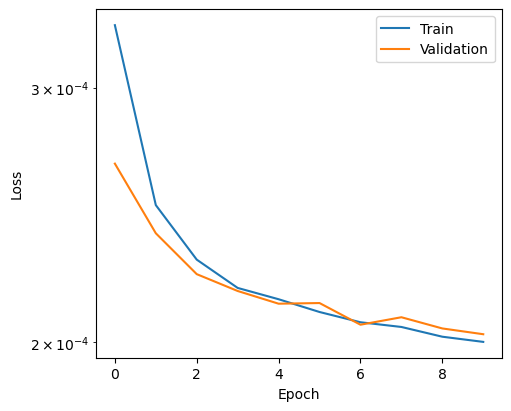

In [13]:
trainer = ANITrainer(model=model, batch_size=8192, learning_rate=1e-3, epoch=10, l2=1e-3)

train_loss, val_loss = trainer.train(train_subset, val_subset, early_stop=False, draw_curve=True)

## Hyperparameter Tuning

In [13]:
#Decrease batch size.

In [14]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [15]:
trainer = ANITrainer(model=model, batch_size=64, learning_rate=1e-3, epoch=10, l2=1e-3)

train_loss, val_loss = trainer.train(train_subset, val_subset, early_stop=False, draw_curve=False)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [10:50<00:00, 65.10s/it]


In [16]:
np.mean(train_loss)

0.00024829448140610636

In [17]:
np.mean(val_loss)

0.0002381514919864824

In [18]:
#Increase batch size.

In [19]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [20]:
trainer = ANITrainer(model=model, batch_size=128, learning_rate=1e-3, epoch=10, l2=1e-3)

train_loss, val_loss = trainer.train(train_subset, val_subset, early_stop=False, draw_curve=False)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:50<00:00, 41.07s/it]


In [21]:
np.mean(train_loss)

0.00023513324453547425

In [22]:
np.mean(val_loss)

0.0002417574843267015

Smaller batches had an overall reduced loss.

### Learning Rate

In [24]:
#Decrease Learning Rate

In [25]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [26]:
trainer = ANITrainer(model=model, batch_size=64, learning_rate=1e-5, epoch=10, l2=1e-3)

train_loss, val_loss = trainer.train(train_subset, val_subset, early_stop=False, draw_curve=False)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [15:02<00:00, 90.27s/it]


In [27]:
np.mean(train_loss)

0.0003160361770201849

In [28]:
np.mean(val_loss)

0.00019066994186602682

In [29]:
#Increase Learning rate

In [16]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [18]:
trainer = ANITrainer(model=model, batch_size=64, learning_rate=1e-2, epoch=10, l2=1e-3)

train_loss, val_loss = trainer.train(train_subset, val_subset, early_stop=False, draw_curve=False)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [11:30<00:00, 69.10s/it]


In [19]:
np.mean(train_loss)

0.0015685425596786528

In [20]:
np.mean(val_loss)

0.0006504799755439805

Lower learning rate significantly reduced loss.

### Regularization (L2)

In [21]:
#Decrease L2

In [14]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [16]:
l2_dec_trainer = ANITrainer(model=model, batch_size=64, learning_rate=1e-2, epoch=10, l2=1e-5)

l2_dec_train_loss, l2_dec_val_loss = l2_dec_trainer.train(train_subset, val_subset, early_stop=False, draw_curve=False)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [07:31<00:00, 45.18s/it]


In [28]:
l2_dec_mean_train_loss = np.mean(l2_dec_train_loss)
l2_dec_mean_train_loss

0.0009450137662795155

In [29]:
l2_dec_mean_val_loss = np.mean(l2_dec_val_loss)
l2_dec_mean_val_loss

0.00029507961363636184

In [26]:
#Increase L2

In [30]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [31]:
l2_inc_trainer = ANITrainer(model=model, batch_size=64, learning_rate=1e-2, epoch=10, l2=1e-2)

l2_inc_train_loss, l2_inc_val_loss = l2_inc_trainer.train(train_subset, val_subset, early_stop=False, draw_curve=False)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [10:35<00:00, 63.60s/it]


In [32]:
l2_inc_mean_train_loss = np.mean(l2_inc_train_loss)
l2_inc_mean_train_loss

0.0027879049046945796

In [33]:
l2_inc_mean_val_loss = np.mean(l2_inc_val_loss)
l2_inc_mean_val_loss

0.0013172215008225617

Decreased L2 had reduced error

### Further Tuning

Learning rate seemed to have the biggest impact on loss, so now I want to find the best learning rate.

In [17]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [18]:
lr_5 = ANITrainer(model=model, batch_size=64, learning_rate=1e-5, epoch=10, l2=1e-5)

lr_5_train_loss, lr_5_val_loss = lr_5.train(train_subset, val_subset, early_stop=False, draw_curve=False)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:45<00:00, 40.51s/it]


In [19]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [20]:
lr_4 = ANITrainer(model=model, batch_size=64, learning_rate=1e-4, epoch=10, l2=1e-5)

lr_4_train_loss, lr_4_val_loss = lr_4.train(train_subset, val_subset, early_stop=False, draw_curve=False)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:45<00:00, 40.55s/it]


In [21]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [22]:
lr_3 = ANITrainer(model=model, batch_size=64, learning_rate=1e-3, epoch=10, l2=1e-5)

lr_3_train_loss, lr_3_val_loss = lr_3.train(train_subset, val_subset, early_stop=False, draw_curve=False)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [06:40<00:00, 40.05s/it]


In [25]:
print("Training Loss:")
print(np.mean(lr_5_train_loss), np.mean(lr_4_train_loss), np.mean(lr_3_train_loss))
print("Val Loss:")
print(np.mean(lr_5_val_loss), np.mean(lr_4_val_loss), np.mean(lr_3_val_loss))

Training Loss:
0.0001649594092812603 8.138178587930523e-05 6.125009043332958e-05
Val Loss:
4.757654081272258e-05 4.070635321546935e-05 3.264848746845882e-05


The best learning rate seems to be 1e-3. Now, we get:

In [26]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 100/100 [08:01<00:00,  4.82s/it]


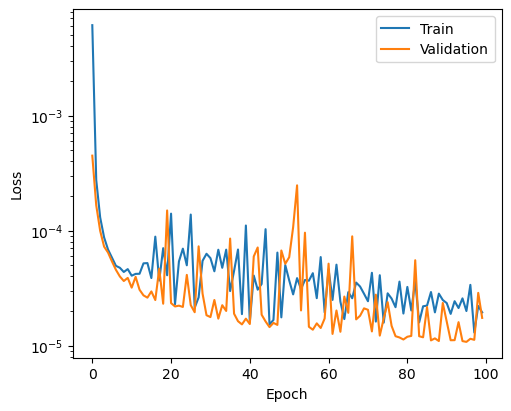

In [27]:
model_test = ANITrainer(model=model, batch_size=8192, learning_rate=1e-3, epoch=100, l2=1e-5)

model_test_train_loss, model_test_val_loss = model_test.train(train_data, val_data, early_stop=False, draw_curve=True)

1.77950336610929e-05

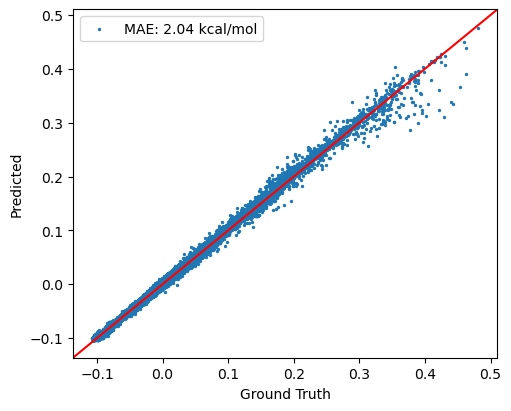

In [28]:
model_test.evaluate(test_data, draw_plot = True)

### Change Batch Size

Previous hyperparameter tuning showed that lower batch sizes had slightly less loss. However, the one used in the previous model is extremely high (taken from chkpt 1). 64 and 128 both run too slowly, so I increased it by a factor of 2.

In [12]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 100/100 [38:07<00:00, 22.88s/it]


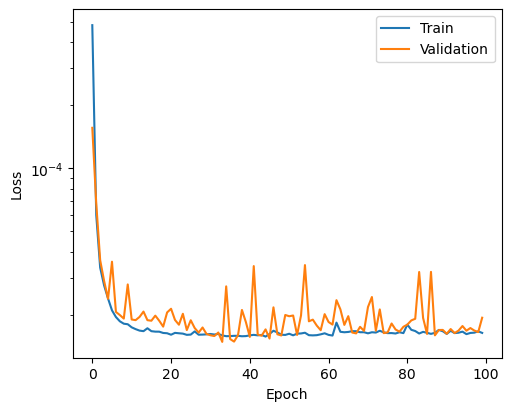

In [13]:
model_test = ANITrainer(model=model, batch_size=256, learning_rate=1e-3, epoch=100, l2=1e-5)

model_test_train_loss, model_test_val_loss = model_test.train(train_data, val_data, early_stop=False, draw_curve=True)

1.85509729575969e-05

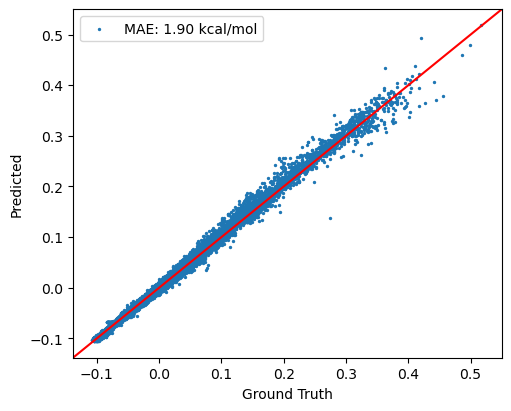

In [14]:
model_test.evaluate(test_data, draw_plot = True)

### K-Fold Cross Validation

Fold 1
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 35/35 [08:23<00:00, 14.38s/it]


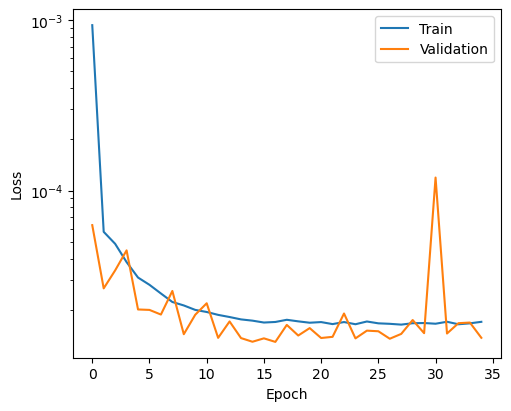

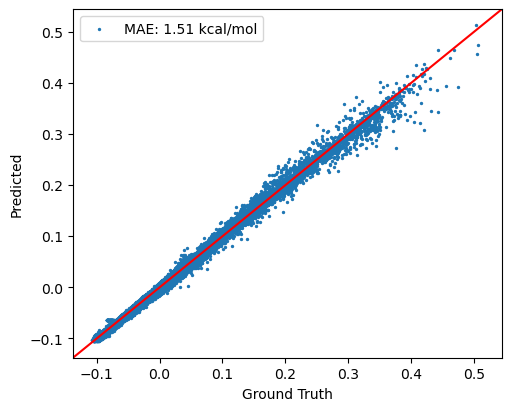

Fold 2
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 35/35 [08:01<00:00, 13.76s/it]


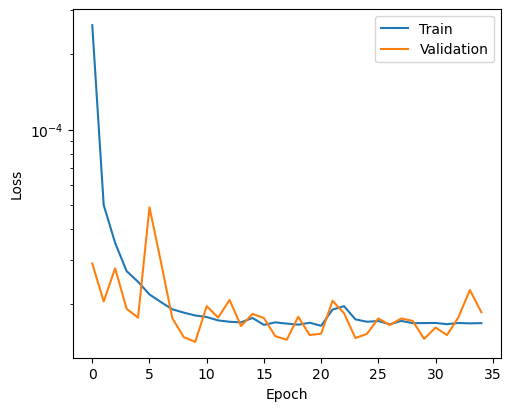

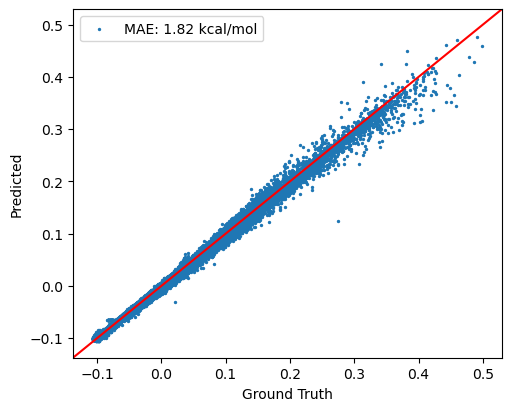

Fold 3
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 35/35 [08:03<00:00, 13.80s/it]


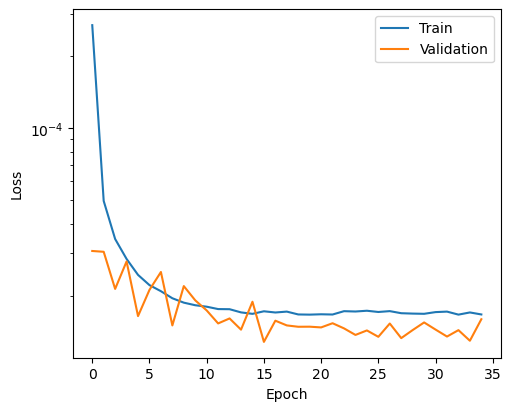

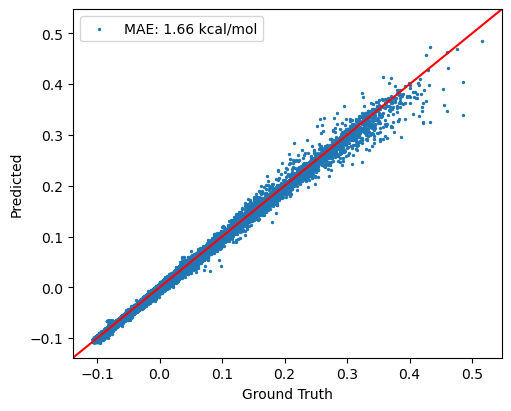

Fold 4
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 35/35 [08:04<00:00, 13.84s/it]


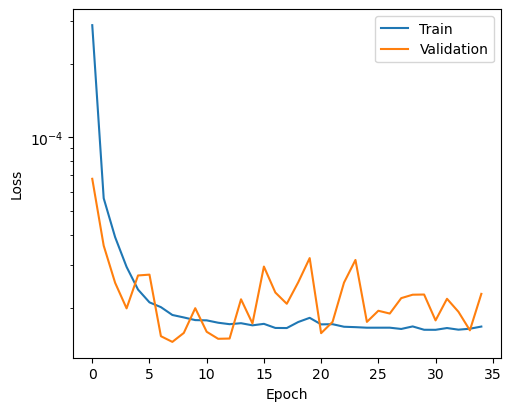

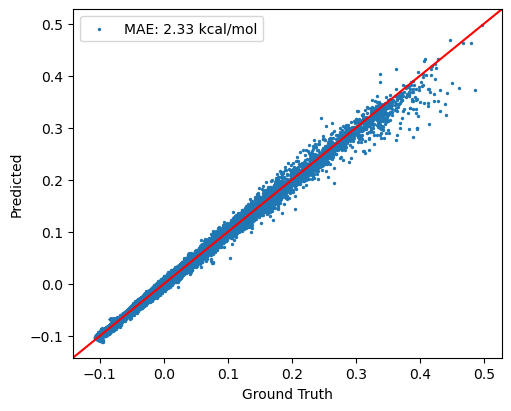

Fold 5
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 35/35 [08:01<00:00, 13.76s/it]


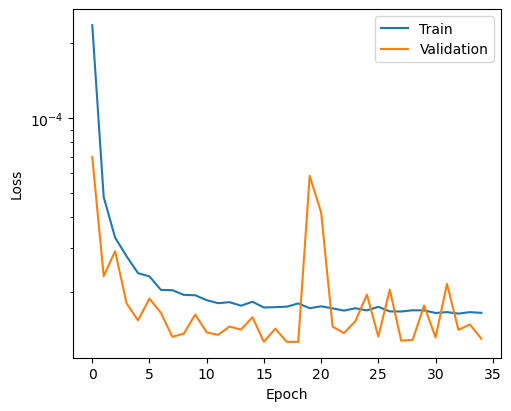

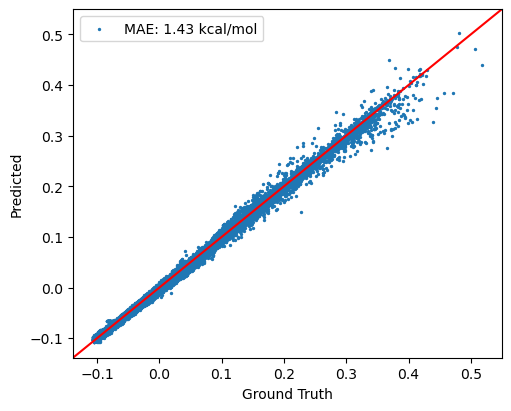

In [8]:
import numpy as np
import torchani

def kFoldCrossValidation(k, train, test, early_break=False):

    indices = np.arange(len(list(train)))  # materialize once safely
    np.random.shuffle(indices)

    splits = np.array_split(indices, k)

    train_list = list(train)  # convert iterable ONCE

    for i in range(k):
        print(f"Fold {i+1}")

        val_idx = set(splits[i])
        train_idx = set(np.concatenate([splits[j] for j in range(k) if j != i]))

        # filter without indexing dataset
        train_wrapped = [
            sample for j, sample in enumerate(train_list)
            if j in train_idx
        ]

        val_wrapped = [
            sample for j, sample in enumerate(train_list)
            if j in val_idx
        ]

        # rebuild TransformableIterable properly
        train_data = torchani.data.TransformableIterable(
            train_wrapped,
            train.transformations
        )
        
        val_data = torchani.data.TransformableIterable(
            val_wrapped,
            train.transformations
        )

        #re-initialize model
        net_H = AtomicNet()
        net_C = AtomicNet()
        net_N = AtomicNet()
        net_O = AtomicNet()

        ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])

        model = nn.Sequential(aev_computer, ani_net).to(device)

        #train/eval on 30 epochs (since we saw on the full dataset that it stopped training by this point anyway)
        trainer = ANITrainer(model=model, batch_size=256, learning_rate=1e-3, epoch=35, l2=1e-5)
        trainer.train(train_data, val_data, early_stop=False, draw_curve=True)
        trainer.evaluate(val_data, draw_plot=True)

        import matplotlib.pyplot as plt
        plt.show()
        plt.close('all')

        if early_break:
            break

kFoldCrossValidation(5, train_data, test_data)

One of the folds had an MAE over 2. However, given the computational limitations of the GPUs, I think that these are the best hyperparameters the model can have at this time. It is also worth noting that it was one fold out of five, and that the fold does not use the full dataset. On the full dataset, the MAE was under 2, so this discrepancy could be due to a reduced dataset.